In [1]:
import sys
from pathlib import Path

# add the project root to Python's module search path so that
# the notebook can import the source code from src/.
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Steane [[7,1,3]] Syndrome Extraction

This notebook develops the stabilizer and syndrome-extraction framework for the Steane $[[7,1,3]]$ quantum error-correcting code and implements the corresponding syndrome measurements in Qiskit.

The goals are to:

- review the stabilizer formalism and fix conventions for the Steane $[[7,1,3]]$ code;
- compute Pauli error syndromes algebraically from commutation relations with the stabilizer generators;
- interpret syndromes in terms of the simultaneous eigenspaces, or syndrome subspaces, of the stabilizer generators;
- verify that the $21$ weight-one Pauli errors have distinct, nonzero syndromes;
- implement ancilla-based stabilizer measurements and complete syndrome extraction;
- prepare the logical state $|0_L\rangle$ and verify its stabilizer properties;
- compare circuit-level syndrome measurements with the algebraic syndrome calculation for all single-qubit Pauli errors.

The focus of this notebook is error detection and syndrome extraction; recovery operations are not implemented here.

## 1. Stabilizer Formalism and Conventions

We follow standard stabilizer-code notation, with conventions influenced by Daniel Gottesman's presentation of the stabilizer formalism [1].

Let

$$
\mathcal{H} \cong (\mathbb{C}^2)^{\otimes n}
$$

be the Hilbert space of an $n$-qubit system. In an idealized model of quantum computation, the state of the system evolves exactly according to the intended sequence of quantum operations. In a physical implementation, however, interactions with the environment and imperfections in physical operations introduce noise and decoherence, which can corrupt the quantum information stored in the system. Quantum error correction addresses this problem by encoding quantum information so that certain errors can be detected and corrected. The stabilizer formalism provides a framework for describing stabilizer codes, detecting Pauli errors through syndrome measurements, and constructing corresponding recovery operations. In this notebook, however, we focus on the detection and syndrome-extraction stages rather than the subsequent recovery procedure.

The stabilizer formalism is built around the $n$-qubit Pauli group

$$
\mathcal{P}_n
=
\left\{
i^\ell P_{n-1}\otimes\cdots\otimes P_0
\;\middle|\;
\ell\in\{0,1,2,3\},
\;
P_j\in\{I,X,Y,Z\}
\text{ for } j=0,\ldots,n-1
\right\},
$$

where

$$
I=
\begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix},
\qquad
X=
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix},
\qquad
Y=
\begin{pmatrix}
0 & -i\\
i & 0
\end{pmatrix},
\qquad
Z=
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix}
$$

denote the single-qubit identity and Pauli $X, Y$, and $Z$ operators, respectively.


The tensor-product Pauli operators

$$
P_{n-1}\otimes\cdots\otimes P_0,
\qquad
P_j\in\{I,X,Y,Z\},
$$

form a basis for the endomorphism algebra $\operatorname{End}(\mathcal{H})$ over $\mathbb{C}$. Thus, arbitrary error operators on $\mathcal{H}$ can be expanded as linear combinations of Pauli operators. This observation underlies the usual discretization of errors in stabilizer quantum error correction and allows errors to be analyzed in terms of Pauli operators. We will refer to an element $E\in\mathcal{P}_n$, when regarded as an error, as a Pauli error.

In the stabilizer formalism, the stabilizer group $S$ of an $[[n,k,d]]$ stabilizer code is an abelian subgroup of $\mathcal{P}_n$, with $-I\notin S$, generated by $n-k$ independent Pauli operators. If

$$
g=i^\ell P_{n-1}\otimes\cdots\otimes P_0\in S,
$$

then the scalar factor $i^\ell$ must be $\pm1$. Indeed, if $i^\ell=\pm i$, then $g^2=-I$, which would imply $-I\in S$. Thus, every element $g\in S$ is Hermitian and satisfies $g^2=I$. It follows that the only possible eigenvalues of $g$ are $\pm1$. Since the elements of $S$ are commuting Hermitian operators, they may be simultaneously diagonalized, so we may consider their simultaneous $+1$ eigenspace. This eigenspace, called the code space, is

$$
T(S)
:=
\left\{
|\psi\rangle
\;\middle|\;
g|\psi\rangle=|\psi\rangle
\text{ for all } g\in S
\right\}.
$$

Since $S$ has $n-k$ independent generators, the code space has dimension

$$
\dim T(S)=2^k.
$$

A code state is a normalized vector $|\psi\rangle\in T(S)$.

A stabilizer code with parameters $[[n,k,d]]$ uses $n$ physical qubits to encode $k$ logical qubits and has distance $d$. In general, a quantum code of distance $d$ can correct all errors of weight at most

$$
t=\left\lfloor\frac{d-1}{2}\right\rfloor.
$$

Thus, the Steane $[[7,1,3]]$ code uses 7 physical qubits to encode 1 logical qubit and can correct any error acting on a single physical qubit.

A generating set for $S$ is not unique. The Steane code has $7-1=6$ independent stabilizer generators. Since it is a CSS code—that is, a stabilizer code whose stabilizer admits an independent generating set in which each generator is either $X$-type or $Z$-type—we may choose the six generators accordingly. For the remainder of this notebook, we fix the following standard CSS generating set presented in IBM Quantum Learning's discussion of CSS codes [2]:

$$
\begin{aligned}
S_1 &= \mathtt{IIIXXXX}, \\
S_2 &= \mathtt{IXXIIXX}, \\
S_3 &= \mathtt{XIXIXIX}, \\
S_4 &= \mathtt{IIIZZZZ}, \\
S_5 &= \mathtt{IZZIIZZ}, \\
S_6 &= \mathtt{ZIZIZIZ}.
\end{aligned}
$$

### Qiskit Qubit Ordering

Qiskit represents an $n$-qubit Pauli operator by a Pauli string in which the rightmost character acts on qubit $0$, the next character acts on qubit $1$, and so on. Accordingly, throughout this notebook we write an $n$-qubit Pauli operator in the form

$$
i^\ell P_{n-1}\otimes\cdots\otimes P_0,
$$

where $P_j$ acts on qubit $j$. Thus, the tensor factors appear from qubit $n-1$ on the left to qubit $0$ on the right, in the same order as the characters of a Qiskit Pauli label.

For example, $S_1=\mathtt{IIIXXXX}$ acts nontrivially on qubits ${0,1,2,3}$, while $S_2=\mathtt{IXXIIXX}$ acts nontrivially on qubits ${0,1,4,5}$.

In [2]:
# import our chosen fixed ordered set of stabilizer generators for the Steane [[7,1,3]] code and print them out
from src.steane import Stabilizers

for index, stabilizer in enumerate(Stabilizers, start=1):
    print(f"S{index} = {stabilizer.to_label()}")

S1 = IIIXXXX
S2 = IXXIIXX
S3 = XIXIXIX
S4 = IIIZZZZ
S5 = IZZIIZZ
S6 = ZIZIZIZ


## 2. Algebraic Syndrome Computation

Let

$$
S=\langle S_1,\ldots,S_{n-k}\rangle
$$

be the stabilizer group of an $[[n,k,d]]$ stabilizer code with a fixed ordered choice of $r:=n-k$ independent generators. This choice determines a syndrome map

$$
s:\mathcal{P}_n\longrightarrow \mathbb{F}_2^r
$$

defined by

$$
s(E)=\bigl(s_1(E),\ldots,s_r(E)\bigr)
$$

for a Pauli error $E\in\mathcal{P}_n$, where

$$
s_i(E)=
\begin{cases}
0, & \text{if } E \text{ commutes with } S_i,\\
1, & \text{if } E \text{ anticommutes with } S_i.
\end{cases}
$$

Since any two Pauli operators either commute or anticommute, exactly one of these two cases occurs for each $i\in\{1,\ldots,r\}$. Equivalently, the $i$-th syndrome bit is characterized by

$$
S_iE=(-1)^{s_i(E)}ES_i.
$$

Thus, the syndrome $s(E)$ records the commutation relations between the error $E$ and the chosen stabilizer generators.

Note moreover that the syndrome map is a group homomorphism when $\mathbb{F}_2^r$ is regarded as an additive group, i.e.,

$$
s(EF)=s(E)+s(F),
$$

where addition on the right-hand side is componentwise modulo $2$. Indeed, the commutation signs with each stabilizer generator multiply under multiplication of Pauli operators, which corresponds to addition of the associated syndrome bits modulo $2$.

The syndrome is also invariant under taking adjoints. To see this, note that since every Pauli operator is unitary, one has

$$
E^\dagger=E^{-1},
$$

and therefore

$$
s(E^\dagger)
=
s(E^{-1})
=
-s(E)
=
s(E),
$$

where the final equality holds because $-x=x$ for every $x\in\mathbb{F}_2^r$.

Finally, observe that multiplication of a Pauli operator by a scalar factor $\pm1$ or $\pm i$ does not change whether it commutes or anticommutes with a stabilizer generator. Thus, the syndrome depends only on the Pauli operator modulo scalar factors. Equivalently, the syndrome map factors through the quotient

$$
\mathcal{P}_n/Z(\mathcal{P}_n),
$$

where

$$
Z(\mathcal{P}_n)
=
\left\{
\pm I^{\otimes n},
\pm iI^{\otimes n}
\right\}
$$

is the center of $\mathcal{P}_n$.

Each Pauli operator $E\in\mathcal{P}_n$ is a unitary operator on $\mathcal{H}$ and therefore acts naturally on state vectors by

$$
|\psi\rangle\longmapsto E|\psi\rangle.
$$

In a chosen basis, this action is represented by matrix-vector multiplication.

Toward understanding the operational meaning of the syndrome, let $|\psi\rangle\in T(S)$ be a code state. Since every stabilizer generator fixes $|\psi\rangle$, one has $S_i|\psi\rangle=|\psi\rangle$ for each $i=1,\ldots,6$. Now suppose a Pauli error $E$ acts on the code state. Then

$$
S_iE|\psi\rangle
=
(-1)^{s_i(E)}ES_i|\psi\rangle
=
(-1)^{s_i(E)}E|\psi\rangle.
$$

Therefore, the corrupted state $E|\psi\rangle$ is a $+1$ eigenstate of $S_i$ when $s_i(E)=0$ and a $-1$ eigenstate when $s_i(E)=1$. Syndrome extraction therefore amounts to determining the eigenvalues of the stabilizer generators on the corrupted state. These measurements reveal information about the error syndrome without revealing the encoded logical state itself.

### Syndrome Subspaces

The syndrome map considered above gives an algebraic description of how Pauli errors interact with the stabilizer generators. We now consider a more structural perspective, obtained by decomposing the physical Hilbert space into simultaneous stabilizer eigenspaces. This provides additional insight into how errors move code states and what information is obtained during syndrome extraction.

Since the stabilizer generators $S_1,\ldots,S_r$ are commuting Hermitian operators, the Hilbert space $\mathcal{H}$ admits an orthogonal decomposition into their simultaneous eigenspaces. For each syndrome vector

$$
a=(a_1,\ldots,a_r)\in\mathbb{F}_2^r,
$$

define the corresponding syndrome subspace

$$
\mathcal{H}_a
:=
\left\{
|\phi\rangle
\;\middle|\;
S_i|\phi\rangle=(-1)^{a_i}|\phi\rangle
\text{ for all } i=1,\ldots,r
\right\}.
$$

These simultaneous eigenspaces form an orthogonal direct-sum decomposition

$$
\mathcal{H}
=
\bigoplus_{a \in\mathbb{F}_2^r}\mathcal{H}_a.
$$

The interpretation of syndromes in terms of simultaneous stabilizer eigenspaces and orthogonal syndrome sectors follows the standard stabilizer formalism; see, for example, Iverson and Preskill [3].

For a stabilizer group generated by $r$ independent Pauli operators, every syndrome vector $a\in\mathbb{F}_2^r$ occurs, and each syndrome subspace has dimension

$$
\dim \mathcal{H}_a
=
2^{n-r}
=
2^k.
$$

Thus, the $2^r$ syndrome subspaces account for the full dimension of the physical Hilbert space:

$$
2^r\cdot 2^{n-r}=2^n.
$$

The code space is precisely the zero-syndrome subspace,

$$
T(S)=\mathcal{H}_{0}.
$$

Now let $|\psi\rangle\in T(S)$ be a code state and let $E\in\mathcal{P}_n$ be a Pauli error. As observed above,

$$
S_iE|\psi\rangle
=
(-1)^{s_i(E)}E|\psi\rangle
$$

for every stabilizer generator $S_i$. Consequently,

$$
E|\psi\rangle\in\mathcal{H}_{s(E)}.
$$

Thus, a Pauli error maps a code state into the syndrome subspace determined by its syndrome, rather than into a linear combination of different syndrome subspaces. In fact, since $E$ is unitary and both $T(S)$ and $\mathcal{H}_{s(E)}$ have dimension $2^k$, the error maps the code space isomorphically onto this syndrome subspace:

$$
E\,T(S)=\mathcal{H}_{s(E)}.
$$

Syndrome extraction determines which of these orthogonal subspaces contains the corrupted state while leaving the encoded logical information within that subspace unmeasured.

### Density-Operator Formulation of Syndrome Extraction

The syndrome-subspace decomposition also admits a natural formulation in terms of density operators and orthogonal projectors. For each syndrome $a=(a_1,\ldots,a_r)\in\mathbb{F}_2^r$, let $\Pi_a\in\operatorname{End}_{\mathbb{C}}(\mathcal{H})$ denote the orthogonal projector onto the syndrome subspace $\mathcal{H}_a$.

Since each stabilizer generator $S_i$ has eigenvalues $\pm1$, the projector onto its $(-1)^{a_i}$ eigenspace is

$$
\frac{I+(-1)^{a_i}S_i}{2}.
$$

Because the stabilizer generators commute, the projector onto their simultaneous eigenspace $\mathcal{H}_a$ is therefore

$$
\Pi_a
=
\prod_{i=1}^r
\frac{I+(-1)^{a_i}S_i}{2}.
$$

These projectors satisfy

$$
\Pi_a\Pi_b=\delta_{a,b}\Pi_a,
\qquad
\sum_{a\in\mathbb{F}_2^r}\Pi_a=I,
$$

and the projector onto the code space $T(S)=\mathcal{H}_0$ is

$$
\Pi_0
=
\prod_{i=1}^r
\frac{I+S_i}{2}.
$$

Now let $\rho\in\operatorname{End}_{\mathbb{C}}(\mathcal{H})$ be a density operator describing the state of the $n$-qubit system, so that $\rho$ is positive semidefinite and $\operatorname{Tr}(\rho)=1$. A measurement of the full stabilizer syndrome returns the syndrome $a$ with probability

$$
p(a)
=
\operatorname{Tr}(\Pi_a\rho).
$$

Provided $p(a)>0$, the corresponding post-measurement state is

$$
\rho_a
=
\frac{\Pi_a\rho\Pi_a}{p(a)}.
$$

Thus, syndrome extraction may be viewed as a projective measurement whose outcomes are indexed by the syndrome vectors $a\in\mathbb{F}_2^r$. In the special case $\rho=|\psi\rangle\langle\psi|$, this reduces to the state-vector picture discussed above, with

$$
p(a)
=
\|\Pi_a|\psi\rangle\|^2.
$$

More formally, the collection of maps

$$
\mathcal{I}_a(\rho)
=
\Pi_a\rho\Pi_a
$$

defines a quantum instrument indexed by $a\in\mathbb{F}_2^r$. The trace $\operatorname{Tr}(\mathcal{I}_a(\rho))$ gives the probability of observing syndrome $a$, while normalizing $\mathcal{I}_a(\rho)$ gives the conditional post-measurement state. Thus, the instrument specifies both the probability of each syndrome outcome and the corresponding conditional post-measurement state.

For the pure-state setting considered throughout most of this notebook, this density-operator formulation is equivalent to the state-vector description above, but it provides a natural framework for treating mixed states, more general noise models, and syndrome extraction as a quantum instrument.

### Syndrome Map for the Steane code

For the Steane $[[7,1,3]]$ code, we have $n=7$ and $r=6$, so the syndrome map is

$$
s:\mathcal{P}_7\longrightarrow\mathbb{F}_2^6.
$$

Throughout the remainder of this notebook, we will make use of the following implementation of the syndrome map for the Steane $[[7,1,3]]$ code. Since any two Pauli operators either commute or anticommute, each syndrome bit is determined by the corresponding commutation test.

``` python
def syndrome(error: Pauli) -> tuple[int, ...]:
    """
    Compute the syndrome of a Pauli error with respect to the six
    Steane stabilizer generators.

    A syndrome bit is 0 if the error commutes with the corresponding
    stabilizer generator and 1 if it anticommutes.
    """
    return tuple(0 if error.commutes(stabilizer) else 1 for stabilizer in Stabilizers)

For the error $E=Z_0 = IIIIIIZ$, the first three syndrome bits are equal to $1$ because each of the $X$-type generators $S_1,S_2,S_3$ acts by $X$ on qubit $0.$ Since $ZX=-XZ,$ the operator $Z_0$ anticommutes with each of these three stabilizer generators.

The generators $S_4,S_5,S_6$ are $Z$-type, and each acts either by $Z$ or
$I$ on qubit $0$. Since $Z$ commutes with both $Z$ and $I$, the error
$Z_0$ commutes with all three $Z$-type generators. Therefore,

$$
s(Z_0)=(1,1,1,0,0,0).
$$


In [3]:
from qiskit.quantum_info import Pauli

from src.steane import syndrome

error = Pauli("IIIIIIZ")  # Z_0

# testing to verify that our syndrome map gives s(Z0)=(1,1,1,0,0,0)
assert syndrome(error) == (1, 1, 1, 0, 0, 0)

### A Note on Pauli Errors and Syndrome Subspaces

So far, we have focused on Pauli errors, for which the syndrome is determined by the commutation or anticommutation of the error with each stabilizer generator. The reason Pauli errors play this central role is rooted in the fact that the tensor-product Pauli operators without scalar phases form a basis for the space of operators on the seven-qubit Hilbert space. Thus, any operator on this space can be expressed as a linear combination

$$
A=\sum_P \alpha_P P,
$$

where the sum ranges over the $4^7$ operators of the form $P=P_6\otimes\cdots\otimes P_0$, with $P_j\in\{I,X,Y,Z\}$ for $j=0,\ldots,6$.

Consequently, if such an operator $A$ acts on a code state $|\psi\rangle$, then

$$
A|\psi\rangle
=
\sum_P \alpha_P P|\psi\rangle.
$$

Different Pauli components $P|\psi\rangle$ may belong to different syndrome subspaces, so the resulting vector need not lie in a single syndrome subspace. Rather, it may have components in several such subspaces. The syndrome measurement described above resolves these components according to their stabilizer eigenvalues and returns the corresponding syndrome.

It is also important that the syndrome does not, in general, uniquely identify a Pauli error. Distinct Pauli errors can have the same syndrome. In particular, if two Pauli errors $E$ and $F$ satisfy $E^\dagger F\in S$, then they differ by a stabilizer element and act identically on the code space. Indeed, if $E^\dagger F=g\in S$, then $F=Eg$, and hence

$$
F|\psi\rangle
=
Eg|\psi\rangle
=
E|\psi\rangle
$$

for every code state $|\psi\rangle\in T(S)$. Such errors are therefore equivalent on the code space and do not need to be distinguished by syndrome measurement.

For the Steane $[[7,1,3]]$ code, however, the $21$ phase-free weight-one Pauli errors

$$
X_i,\qquad Y_i,\qquad Z_i,
\qquad i=0,\ldots,6,
$$

have distinct, nonzero syndromes. Thus, every weight0one Pauli error is distinguished by its syndrome, consistent with the ability of the distance-$3$ Steane code to correct an arbitrary error acting on a single physical qubit.

## 3. Weight-One Pauli Errors

Since the Steane code has distance $d=3$, it can correct an arbitrary error acting on a single physical qubit. For Pauli errors, this means considering the $21$ weight-one operators

$$
X_j,\qquad Y_j,\qquad Z_j,
\qquad j=0,\ldots,6.
$$

Here $X_j$, $Y_j$, and $Z_j$ denote the corresponding Pauli operator acting on qubit $j$ and the identity on all other qubits.

For example, using Qiskit's Pauli-string convention,

$$
Z_0=\mathtt{IIIIIIZ},
$$

while

$$
Z_6=\mathtt{ZIIIIII}.
$$

For the Steane code, each of the $21$ weight-one Pauli errors has a nonzero syndrome, and no two of these errors have the same syndrome. Thus, the syndrome uniquely identifies any single-qubit Pauli error.

In [4]:
# We verify the claim that we have just made.

# First we round em all up
weight_one_errors = []

# make all of the single-qubit Pauli errors and put them into the list above, together with the type of the error,
# qubit index corresponding to the support of the operator, and the syndrome of that error
for pauli_type in ["X", "Y", "Z"]:
    for qubit_index in range(7):
        pauli_label = "I" * (6 - qubit_index) + pauli_type + "I" * qubit_index
        error = Pauli(pauli_label)

        weight_one_errors.append((pauli_type, qubit_index, error, syndrome(error)))

# let's print things to make sure everything looks ok
for pauli_type, qubit_index, error, error_syndrome in weight_one_errors:
    print(f"{pauli_type}_{qubit_index}: {error.to_label()} -> {error_syndrome}")

X_0: IIIIIIX -> (0, 0, 0, 1, 1, 1)
X_1: IIIIIXI -> (0, 0, 0, 1, 1, 0)
X_2: IIIIXII -> (0, 0, 0, 1, 0, 1)
X_3: IIIXIII -> (0, 0, 0, 1, 0, 0)
X_4: IIXIIII -> (0, 0, 0, 0, 1, 1)
X_5: IXIIIII -> (0, 0, 0, 0, 1, 0)
X_6: XIIIIII -> (0, 0, 0, 0, 0, 1)
Y_0: IIIIIIY -> (1, 1, 1, 1, 1, 1)
Y_1: IIIIIYI -> (1, 1, 0, 1, 1, 0)
Y_2: IIIIYII -> (1, 0, 1, 1, 0, 1)
Y_3: IIIYIII -> (1, 0, 0, 1, 0, 0)
Y_4: IIYIIII -> (0, 1, 1, 0, 1, 1)
Y_5: IYIIIII -> (0, 1, 0, 0, 1, 0)
Y_6: YIIIIII -> (0, 0, 1, 0, 0, 1)
Z_0: IIIIIIZ -> (1, 1, 1, 0, 0, 0)
Z_1: IIIIIZI -> (1, 1, 0, 0, 0, 0)
Z_2: IIIIZII -> (1, 0, 1, 0, 0, 0)
Z_3: IIIZIII -> (1, 0, 0, 0, 0, 0)
Z_4: IIZIIII -> (0, 1, 1, 0, 0, 0)
Z_5: IZIIIII -> (0, 1, 0, 0, 0, 0)
Z_6: ZIIIIII -> (0, 0, 1, 0, 0, 0)


In [5]:
# extract just the error syndromes
weight_one_syndromes = []

for i in range(len(weight_one_errors)):
    weight_one_syndromes.append(weight_one_errors[i][3])

# verify that all 21 weight-one Pauli errors have distinct nonzero syndromes.
assert len(weight_one_syndromes) == 21
assert len(set(weight_one_syndromes)) == len(weight_one_syndromes)
assert (0, 0, 0, 0, 0, 0) not in weight_one_syndromes

The computation above verifies that the $21$ weight-one Pauli errors have distinct, nonzero syndromes. Thus, for the Steane code, the syndrome uniquely identifies both the physical qubit on which a single-qubit Pauli error occurred and the type of Pauli error.

This is consistent with the distance $d=3$ of the Steane code, which guarantees that arbitrary errors affecting a single physical qubit are correctable.

There are $2^6=64$ possible syndrome vectors for the Steane code, of which $63$ are nonzero. The $21$ weight-one Pauli errors considered here therefore realize only a subset of the possible nonzero syndromes; higher-weight Pauli errors account for the remaining syndrome vectors.

## 4. Ancilla-Based Stabilizer Measurement

The algebraic syndrome computation tells us the eigenvalue of each stabilizer generator on a code state after a Pauli error has occurred. To extract this information from a quantum circuit, we would like to determine whether the data state lies in the $+1$ or $-1$ eigenspace of a stabilizer operator without directly measuring the data qubits.

Let $g \in S$ be a stabilizer operator, and suppose the data register is in an eigenstate $|\psi\rangle$ of $g$ with eigenvalue

$$
\lambda\in\{+1,-1\}.
$$

Thus,

$$
g|\psi\rangle=\lambda|\psi\rangle.
$$

Introduce an ancilla qubit initialized in the state $|0\rangle$. After applying a Hadamard gate to the ancilla, the joint state becomes

$$
|+\rangle|\psi\rangle
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle|\psi\rangle
+
|1\rangle|\psi\rangle
\right).
$$

Next, apply a controlled-$g$ operation with the ancilla as the control and the data register as the target. The resulting state is

$$
\frac{1}{\sqrt{2}}
\left(
|0\rangle|\psi\rangle
+
|1\rangle g|\psi\rangle
\right).
$$

Since $|\psi\rangle$ is an eigenstate of $g$, we have

$$
\frac{1}{\sqrt{2}}
\left(
|0\rangle|\psi\rangle
+
|1\rangle g|\psi\rangle
\right)
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
\lambda|1\rangle
\right)
|\psi\rangle.
$$

Thus, the eigenvalue of $g$ has been transferred to the relative phase of the ancilla. If $\lambda=+1$, the ancilla is in the state

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt{2}},
$$

while if $\lambda=-1$, it is in the state

$$
|-\rangle
=
\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

Applying a second Hadamard gate gives $H|+\rangle=|0\rangle$ and $H|-\rangle=|1\rangle.$

Thus, measuring the ancilla in the computational basis returns

$$
0
\quad\text{if}\quad
\lambda=+1,
$$

and

$$
1
\quad\text{if}\quad
\lambda=-1.
$$

The stabilizer eigenvalue is therefore encoded as a classical bit in the ancilla measurement outcome. In particular, if $|\psi\rangle\in T(S)$ is a code state and $E$ is a Pauli error, then for each stabilizer generator $S_i$ of $S$, we have

$$
S_iE|\psi\rangle
=
(-1)^{s_i(E)}E|\psi\rangle.
$$

Measuring the stabilizer generator $S_i$ by this procedure therefore returns exactly the syndrome bit $s_i(E)$.

### Implementing the Controlled Stabilizer

Each Steane stabilizer generator is a tensor product of single-qubit Pauli operators. Since our chosen generators contain only $I$ and $X,$ or only $I$ and $Z,$ the controlled-$S_i$ operation can be decomposed into standard controlled-Pauli gates.

For an $X$-type stabilizer, every occurrence of $X$ in the Pauli string contributes a controlled-$X$ gate, or CNOT, with the ancilla as the control and the corresponding data qubit as the target. For example,

$$
S_1=\mathtt{IIIXXXX}
$$

acts nontrivially on data qubits $0,1,2,3$, so a controlled-$S_1$ operation is implemented by applying

$$
CX_{a,0}\,
CX_{a,1}\,
CX_{a,2}\,
CX_{a,3},
$$

where $a$ denotes the ancilla qubit.

Similarly, for a $Z$-type stabilizer, every occurrence of $Z$ contributes a controlled-$Z$ gate between the ancilla and the corresponding data qubit. For example,

$$
S_4=\mathtt{IIIZZZZ}
$$

is implemented by

$$
CZ_{a,0}\,
CZ_{a,1}\,
CZ_{a,2}\,
CZ_{a,3}.
$$

Because the single-qubit Pauli factors act on distinct data qubits, these controlled operations together implement the controlled version of the full tensor-product stabilizer.

To demonstrate the implementation, we first construct the ancilla-based circuit used to measure the stabilizer generator

$$
S_1=\mathtt{IIIXXXX}.
$$

The circuit uses a single ancilla qubit to encode the eigenvalue of $S_1$ into a classical measurement outcome without directly measuring the data qubits. The resulting circuit is displayed below.

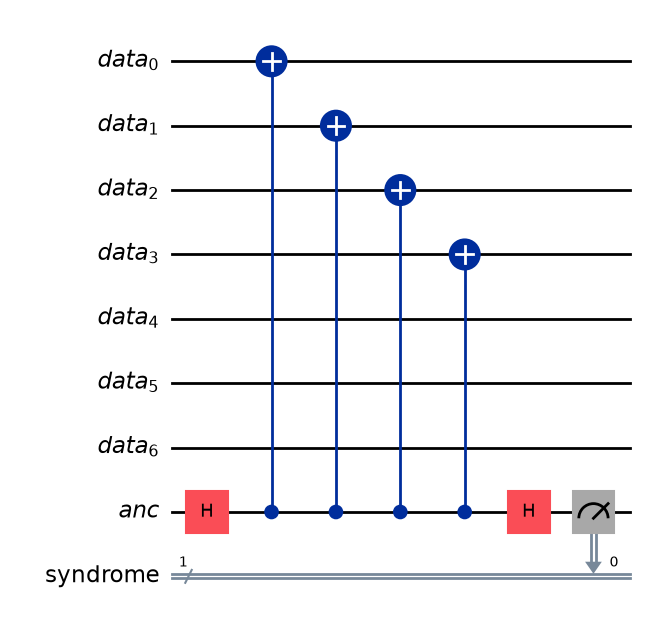

In [6]:
from qiskit.circuit import (
    AncillaRegister,
    ClassicalRegister,
    QuantumCircuit,
    QuantumRegister,
)

data = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bit)

# apply a hadamard to the ancilla qubit
qc.h(ancilla)

# implement the controlled S_1 gate
qc.cx(ancilla[0], data[0])
qc.cx(ancilla[0], data[1])
qc.cx(ancilla[0], data[2])
qc.cx(ancilla[0], data[3])

# another hadamard on the ancilla
qc.h(ancilla)

# thenw e measure
qc.measure(ancilla, syndrome_bit)


qc.draw(output="mpl")

We now test the single-stabilizer measurement circuit. The circuit below prepares the $+1$ eigenstate

$$
|+\rangle^{\otimes 7}
=
|+++++++\rangle
$$

of $S_1$, performs the ancilla-based stabilizer measurement, and uses `AerSimulator` to run the circuit for 100 shots. Since the measurement outcome is deterministic for this eigenstate, we expect to obtain the syndrome bit $0$, corresponding to the eigenvalue $+1$ of $S_1$, in every shot.

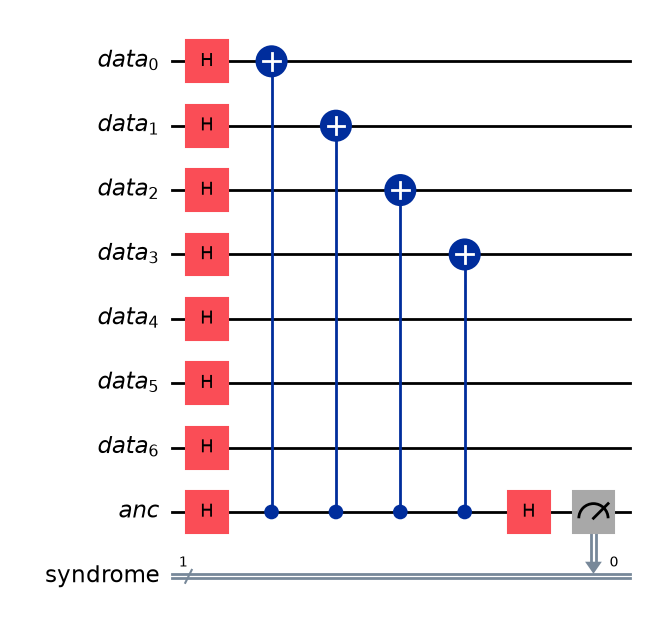

In [7]:
from qiskit_aer import AerSimulator

data = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bit)

# prepare |+>^7
for i in range(7):
    qc.h(data[i])

# measure S_1 = IIIXXXX
qc.h(ancilla[0])

qc.cx(ancilla[0], data[0])
qc.cx(ancilla[0], data[1])
qc.cx(ancilla[0], data[2])
qc.cx(ancilla[0], data[3])

qc.h(ancilla[0])
qc.measure(ancilla[0], syndrome_bit[0])

qc.draw(output="mpl")

In [8]:
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'0': 100}

We next test the same measurement circuit on a $-1$ eigenstate of $S_1$. Starting from $|+\rangle^{\otimes 7}$, we apply a $Z_0$ error to data qubit $0$. Since $Z_0$ anticommutes with $S_1$, this changes the stabilizer eigenvalue from $+1$ to $-1$. We therefore expect the ancilla measurement to return the syndrome bit $1$ in every shot.

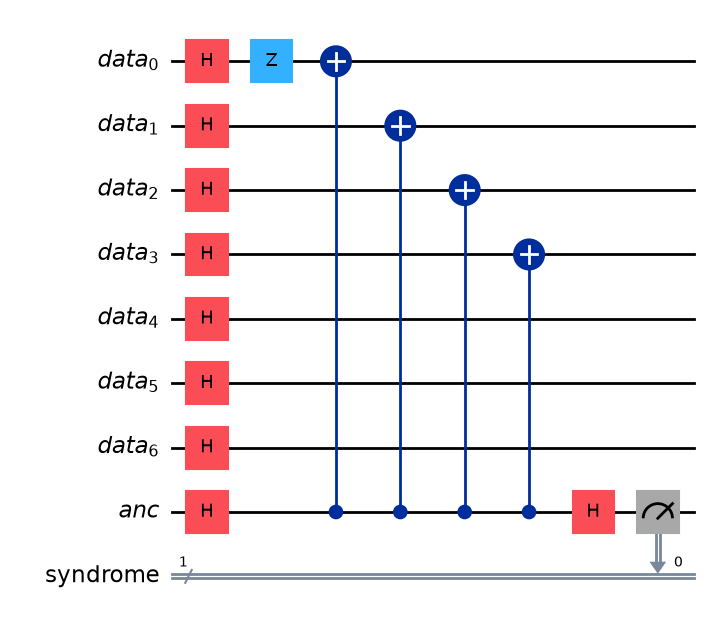

In [9]:
data = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bit)

# prepare |+>^7
for i in range(7):
    qc.h(data[i])

# apply Z_0 error
qc.z(data[0])

# measure S_1 = IIIXXXX
qc.h(ancilla[0])

qc.cx(ancilla[0], data[0])
qc.cx(ancilla[0], data[1])
qc.cx(ancilla[0], data[2])
qc.cx(ancilla[0], data[3])

qc.h(ancilla[0])
qc.measure(ancilla[0], syndrome_bit[0])

qc.draw(output="mpl")

In [10]:
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()
counts

{'1': 100}

The two examples above measure only the single stabilizer generator $S_1$. Since the same ancilla-based construction applies to every Steane stabilizer generator, we now generalize this circuit into a reusable function, which we call `measure_stabilizer`.

Given a stabilizer Pauli string, the function identifies each nonidentity Pauli factor and applies the corresponding controlled operation from the ancilla to the appropriate data qubit. An $X$ factor is implemented using a controlled-$X$ gate, while a $Z$ factor is implemented using a controlled-$Z$ gate. Identity factors require no operation.

Because Qiskit places qubit $0$ at the rightmost end of a Pauli string, the stabilizer label is read in reverse order when matching Pauli factors to data-qubit indices.

The implementation used in this project is:

```python
def measure_stabilizer(
    qc: QuantumCircuit,
    data: QuantumRegister,
    ancilla: AncillaRegister,
    syndrome_bits: ClassicalRegister,
    stabilizer: Pauli,
    index: int,
) -> None:
    """
    Append an ancilla-based measurement of one Steane stabilizer.

    The circuit is modified in place. The ancilla and classical bit at
    `index` store the measurement associated with the supplied stabilizer.

    Assumes the stabilizer contains only I, X, and Z factors and uses
    Qiskit's convention that qubit 0 is the rightmost Pauli-string entry.
    """
    label = stabilizer.to_label()
    
    if any(pauli not in "IXZ" for pauli in label):
        raise ValueError("Stabilizer must contain only I, X, and Z factors.")
    
    qc.h(ancilla[index])

    # qiskit Pauli labels place qubit 0 at the rightmost character.
    for qubit_index, pauli in enumerate(reversed(label)):
        if pauli == "X":
            qc.cx(ancilla[index], data[qubit_index])
        elif pauli == "Z":
            qc.cz(ancilla[index], data[qubit_index])

    qc.h(ancilla[index])
    qc.measure(ancilla[index], syndrome_bits[index])
```

We import this function from `src.steane` for use throughout the remainder of the notebook.

In [11]:
from src.steane import measure_stabilizer

We perform two quick tests to verify that `measure_stabilizer` reproduces the same outcomes as our hand-written circuits and correctly handles both $X$-type and $Z$-type stabilizer generators.

In [12]:
# check 1: verify that measure_stabilizer correctly handles an X-type
# stabilizer. The state |+>^7 is a +1 eigenstate of S_1 = IIIXXXX.

data = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bit)

# prepare |+>^7
for i in range(7):
    qc.h(data[i])

measure_stabilizer(
    qc,
    data,
    ancilla,
    syndrome_bit,
    Stabilizers[0],
    0,
)

simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()

counts

{'0': 100}

In [13]:
# check 2: verify that measure_stabilizer also handles a Z-type
# stabilizer correctly. The default state |0000000> is a +1
# eigenstate of S_4 = IIIZZZZ.


data = QuantumRegister(7, "data")
ancilla = AncillaRegister(1, "anc")
syndrome_bit = ClassicalRegister(1, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bit)


measure_stabilizer(
    qc,
    data,
    ancilla,
    syndrome_bit,
    Stabilizers[3],
    0,
)

simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()

counts

{'0': 100}

### Full Syndrome Extraction

To determine the complete syndrome of an error, we measure each of the six stabilizer generators $S_1,\ldots,S_6.$

Each stabilizer measurement produces one syndrome bit. We therefore use six ancilla qubits and six classical bits, with the measurement of $S_i$ stored in the corresponding classical bit.

The function `append_syndrome_measurement` applies `measure_stabilizer` once for each stabilizer generator, thereby appending the complete syndrome-extraction circuit to an existing quantum circuit.

In [14]:
from src.steane import append_syndrome_measurement

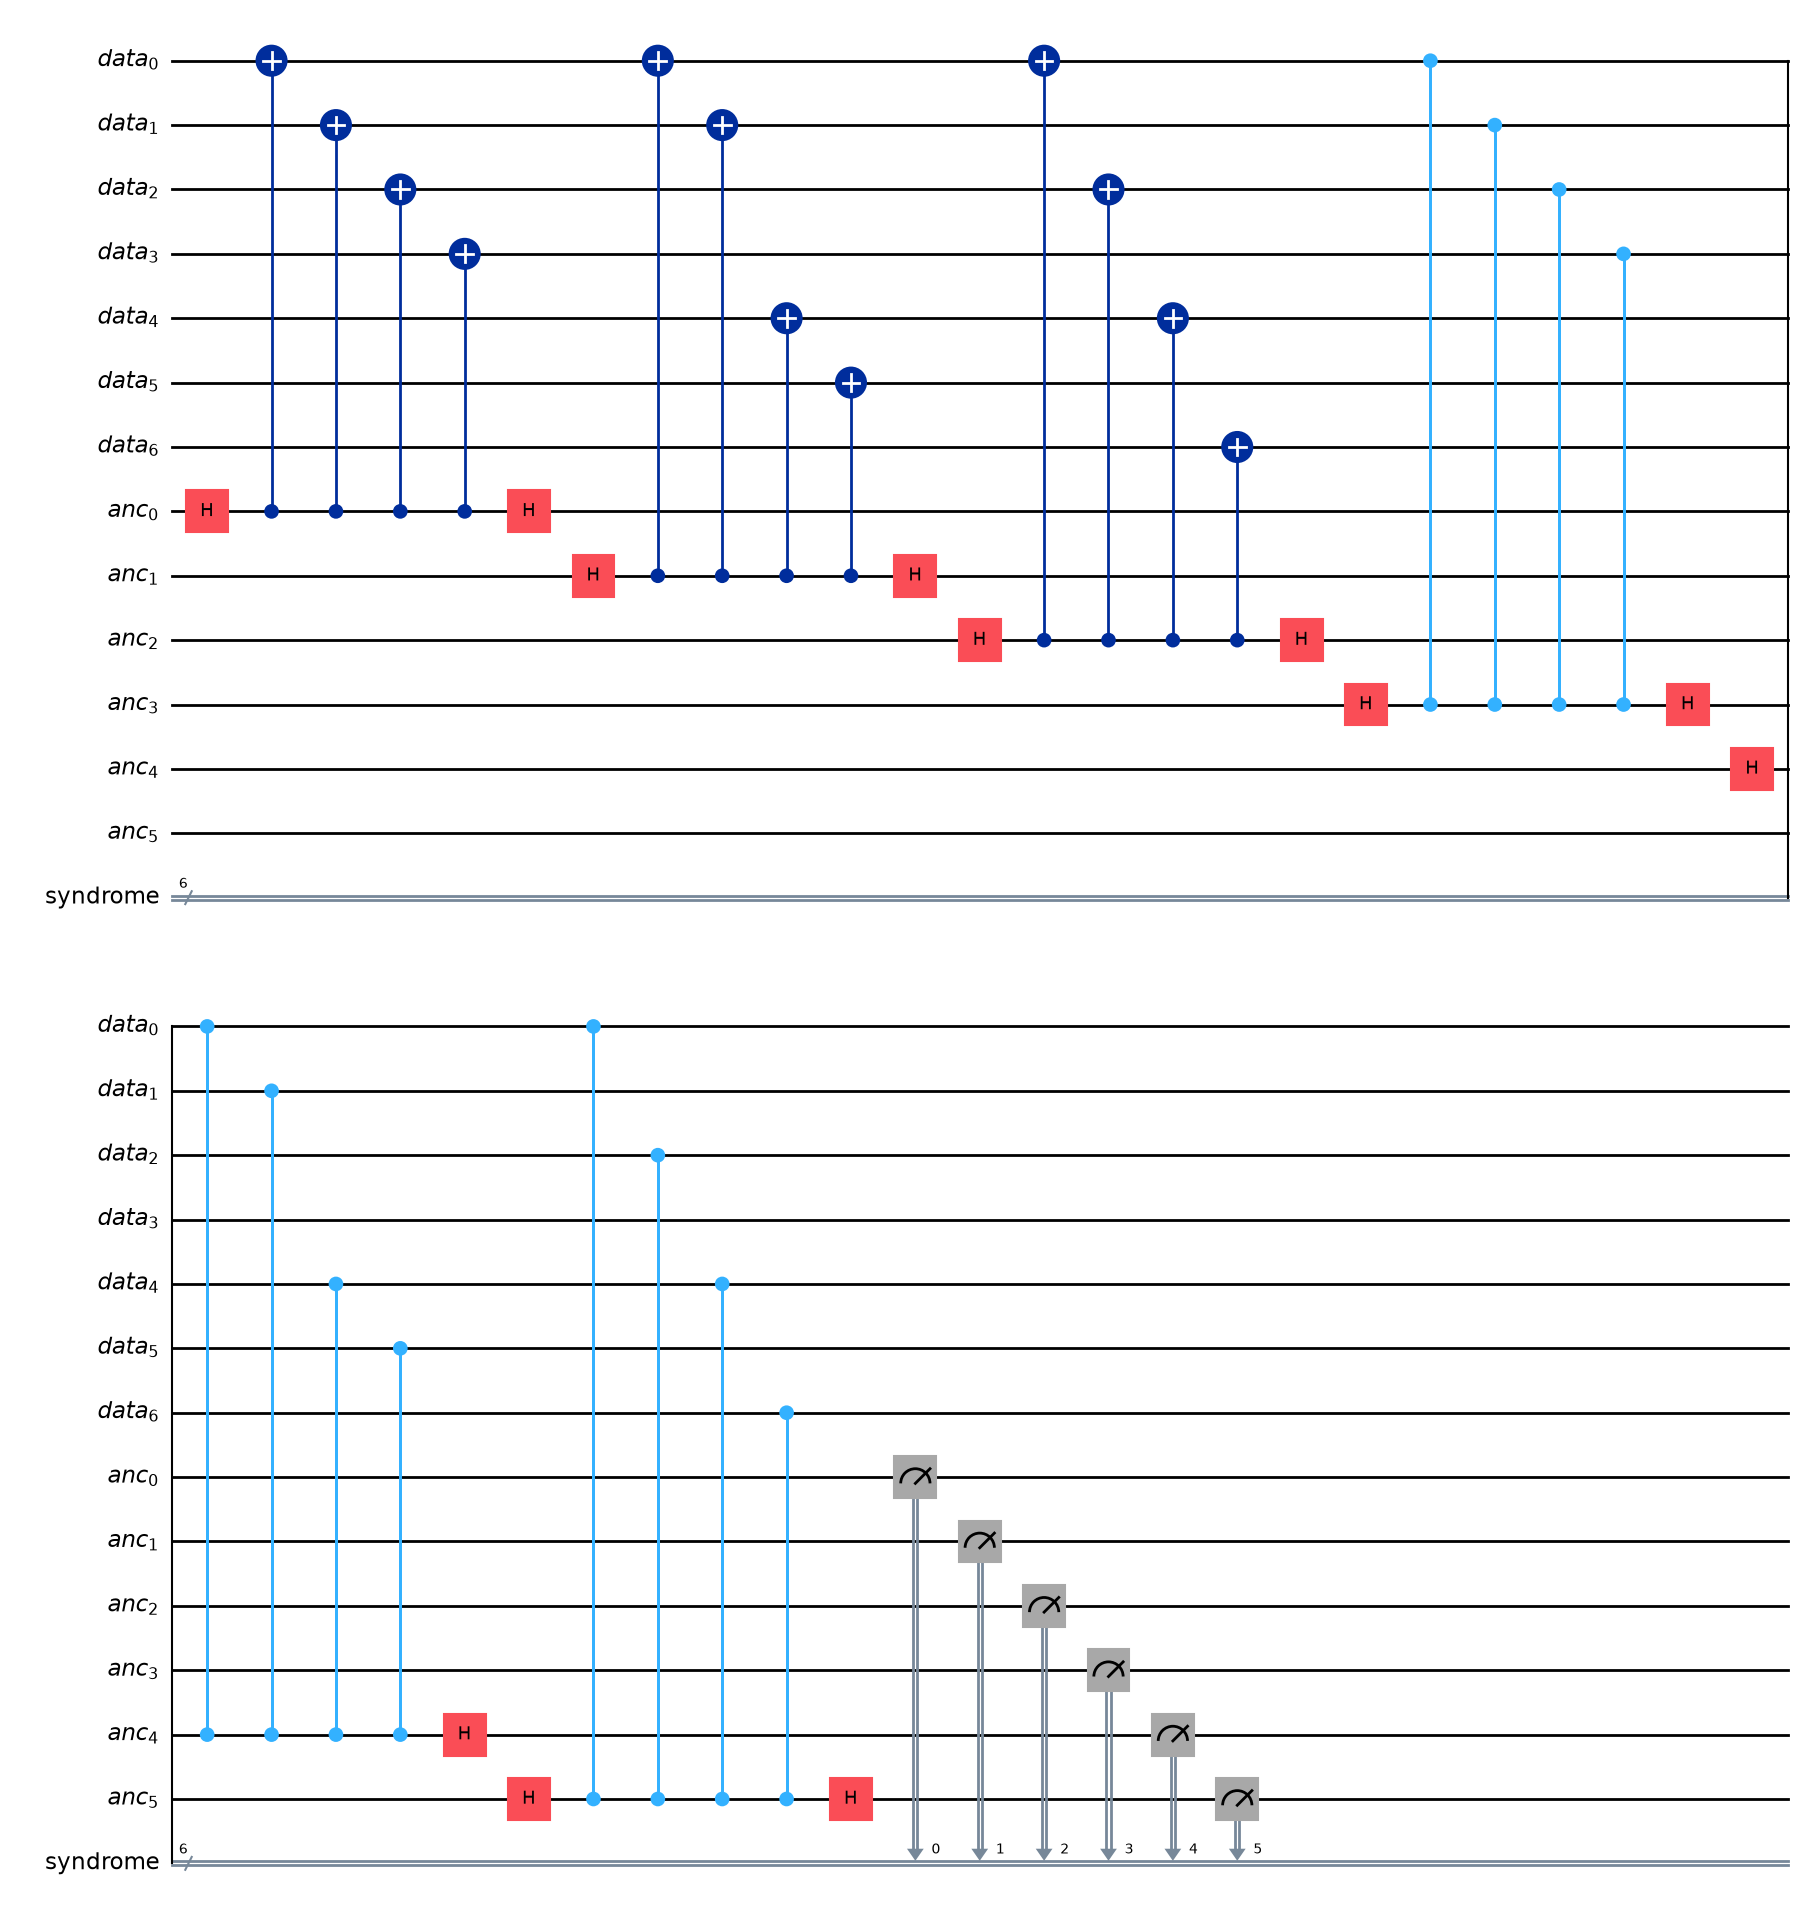

In [15]:
# demonstrate the circuit produced by append_syndrome_measurement

data = QuantumRegister(7, "data")
ancilla = AncillaRegister(6, "anc")
syndrome_bits = ClassicalRegister(6, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bits)

append_syndrome_measurement(
    qc,
    data,
    ancilla,
    syndrome_bits,
)

# using the keyword justify="none" preserves the order in which the stabilizer-
# measurement operations were appended for S_1, ..., S_6.
qc.draw(output="mpl", justify="none")

### Preparing a Steane Code State

To test the full syndrome-extraction circuit, the data register should first be prepared in a state belonging to the Steane code space. We therefore choose a particular logical computational-basis state within the two-dimensional code space $T(S)$.

We choose

$$
Z_L=Z^{\otimes 7}
$$

as a representative of the logical $Z$ operator. This operator commutes with every stabilizer generator, so it preserves the code space, but it is not itself an element of the stabilizer group and therefore acts nontrivially on the encoded qubit.

We define the logical state $|0_L\rangle$ to be the simultaneous $+1$ eigenstate of

$$
S_1,\ldots,S_6,Z_L.
$$

These seven commuting Pauli operators uniquely specify the state $|0_L\rangle$. For the present project, we use Qiskit's `synth_circuit_from_stabilizers` routine to construct a circuit preparing the simultaneous $+1$-eigenstate of the specified stabilizers [4]; the focus here is syndrome extraction rather than optimization of the encoding circuit. .

In [16]:
# we prepare the logical computational basis state |0_L>

from qiskit.synthesis import synth_circuit_from_stabilizers

logical_zero_stabilizers = [stabilizer.to_label() for stabilizer in Stabilizers] + [
    "ZZZZZZZ"
]

logical_zero_circuit = synth_circuit_from_stabilizers(logical_zero_stabilizers)

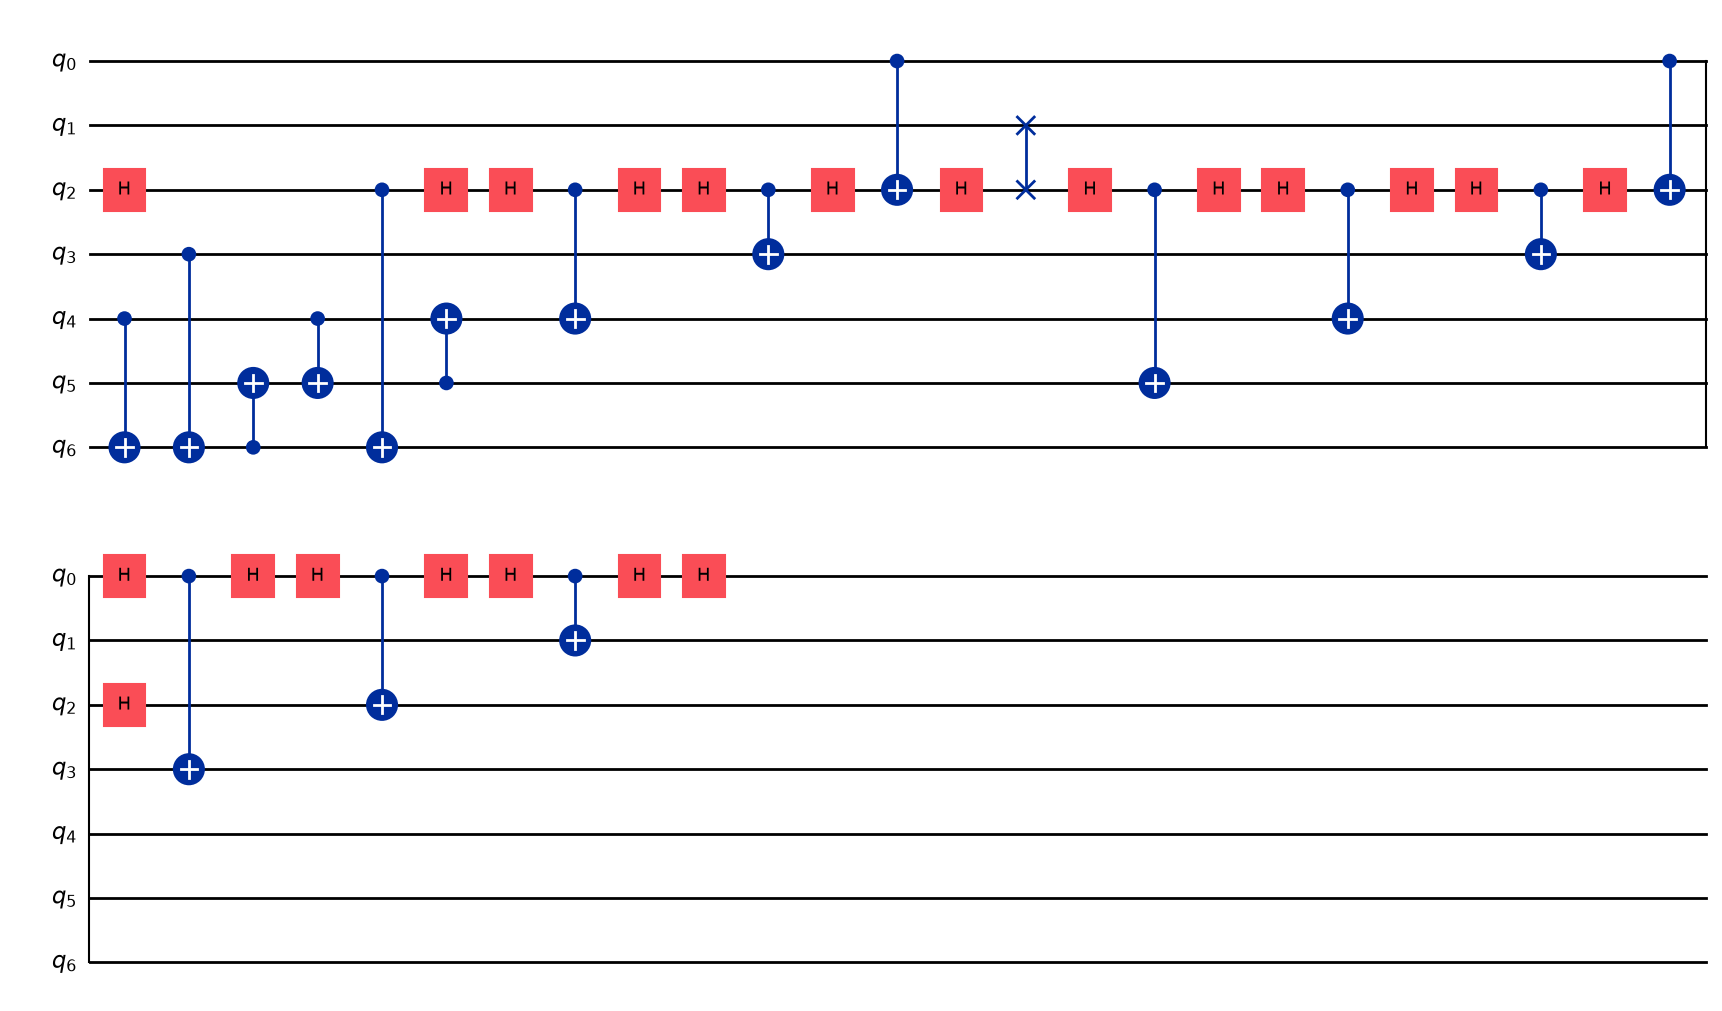

In [17]:
# let's take a look under the hood here
logical_zero_circuit.draw(output="mpl")

We can now append the full six-stabilizer syndrome measurement to the logical-zero preparation circuit and simulate the no-error case. Since $|0_L\rangle$ lies in the code space, it is a $+1$ eigenstate of every stabilizer generator. We therefore expect the measured syndrome to be

$$
(0,0,0,0,0,0).
$$

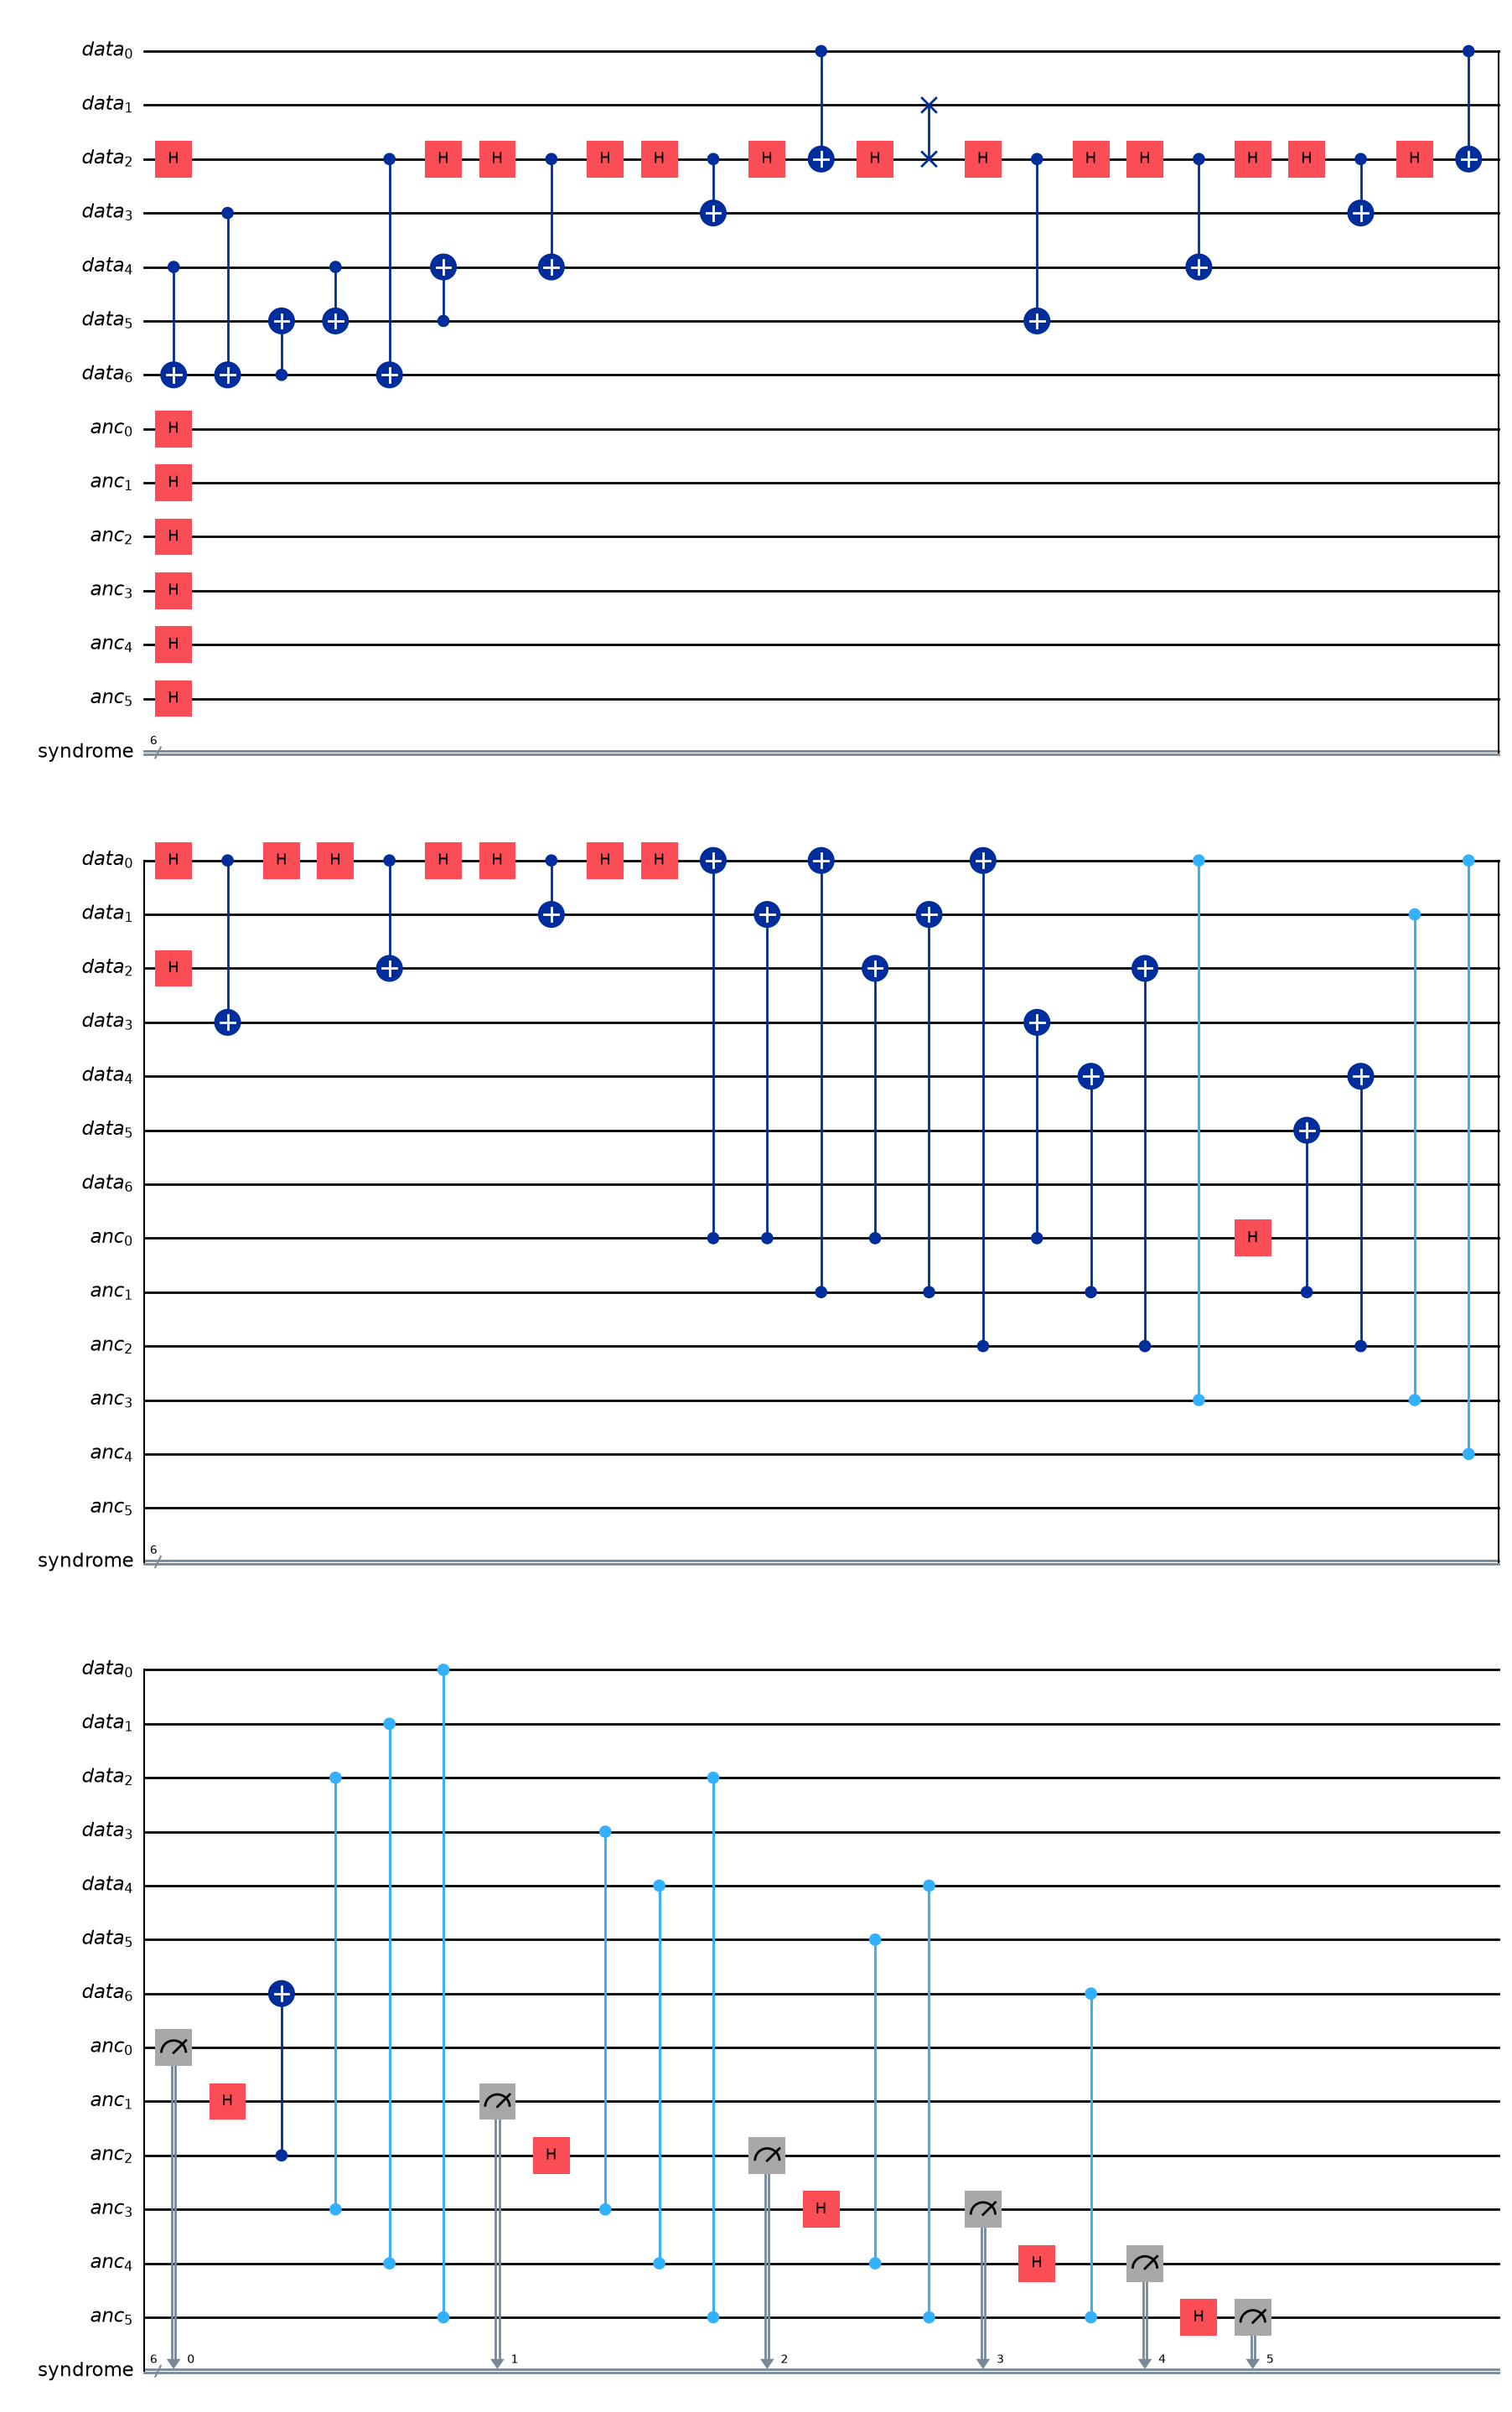

In [18]:
data = QuantumRegister(7, "data")
ancilla = AncillaRegister(6, "anc")
syndrome_bits = ClassicalRegister(6, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bits)

# prepare the logical computational basis state |0_L>
qc.compose(logical_zero_circuit, qubits=data, inplace=True)

# append the six stabilizer measurements
append_syndrome_measurement(
    qc,
    data,
    ancilla,
    syndrome_bits,
)


qc.draw(output="mpl")

In [19]:
# now we simulate the no-error case and verify that we get the correct syndrome
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()

counts

{'000000': 100}

We can now introduce a Pauli error, say

$$
Z_0=\mathtt{IIIIIIZ},
$$

and compare the syndrome obtained from the ancilla-based stabilizer measurement with the algebraic syndrome computed by `syndrome(Z_0)`.

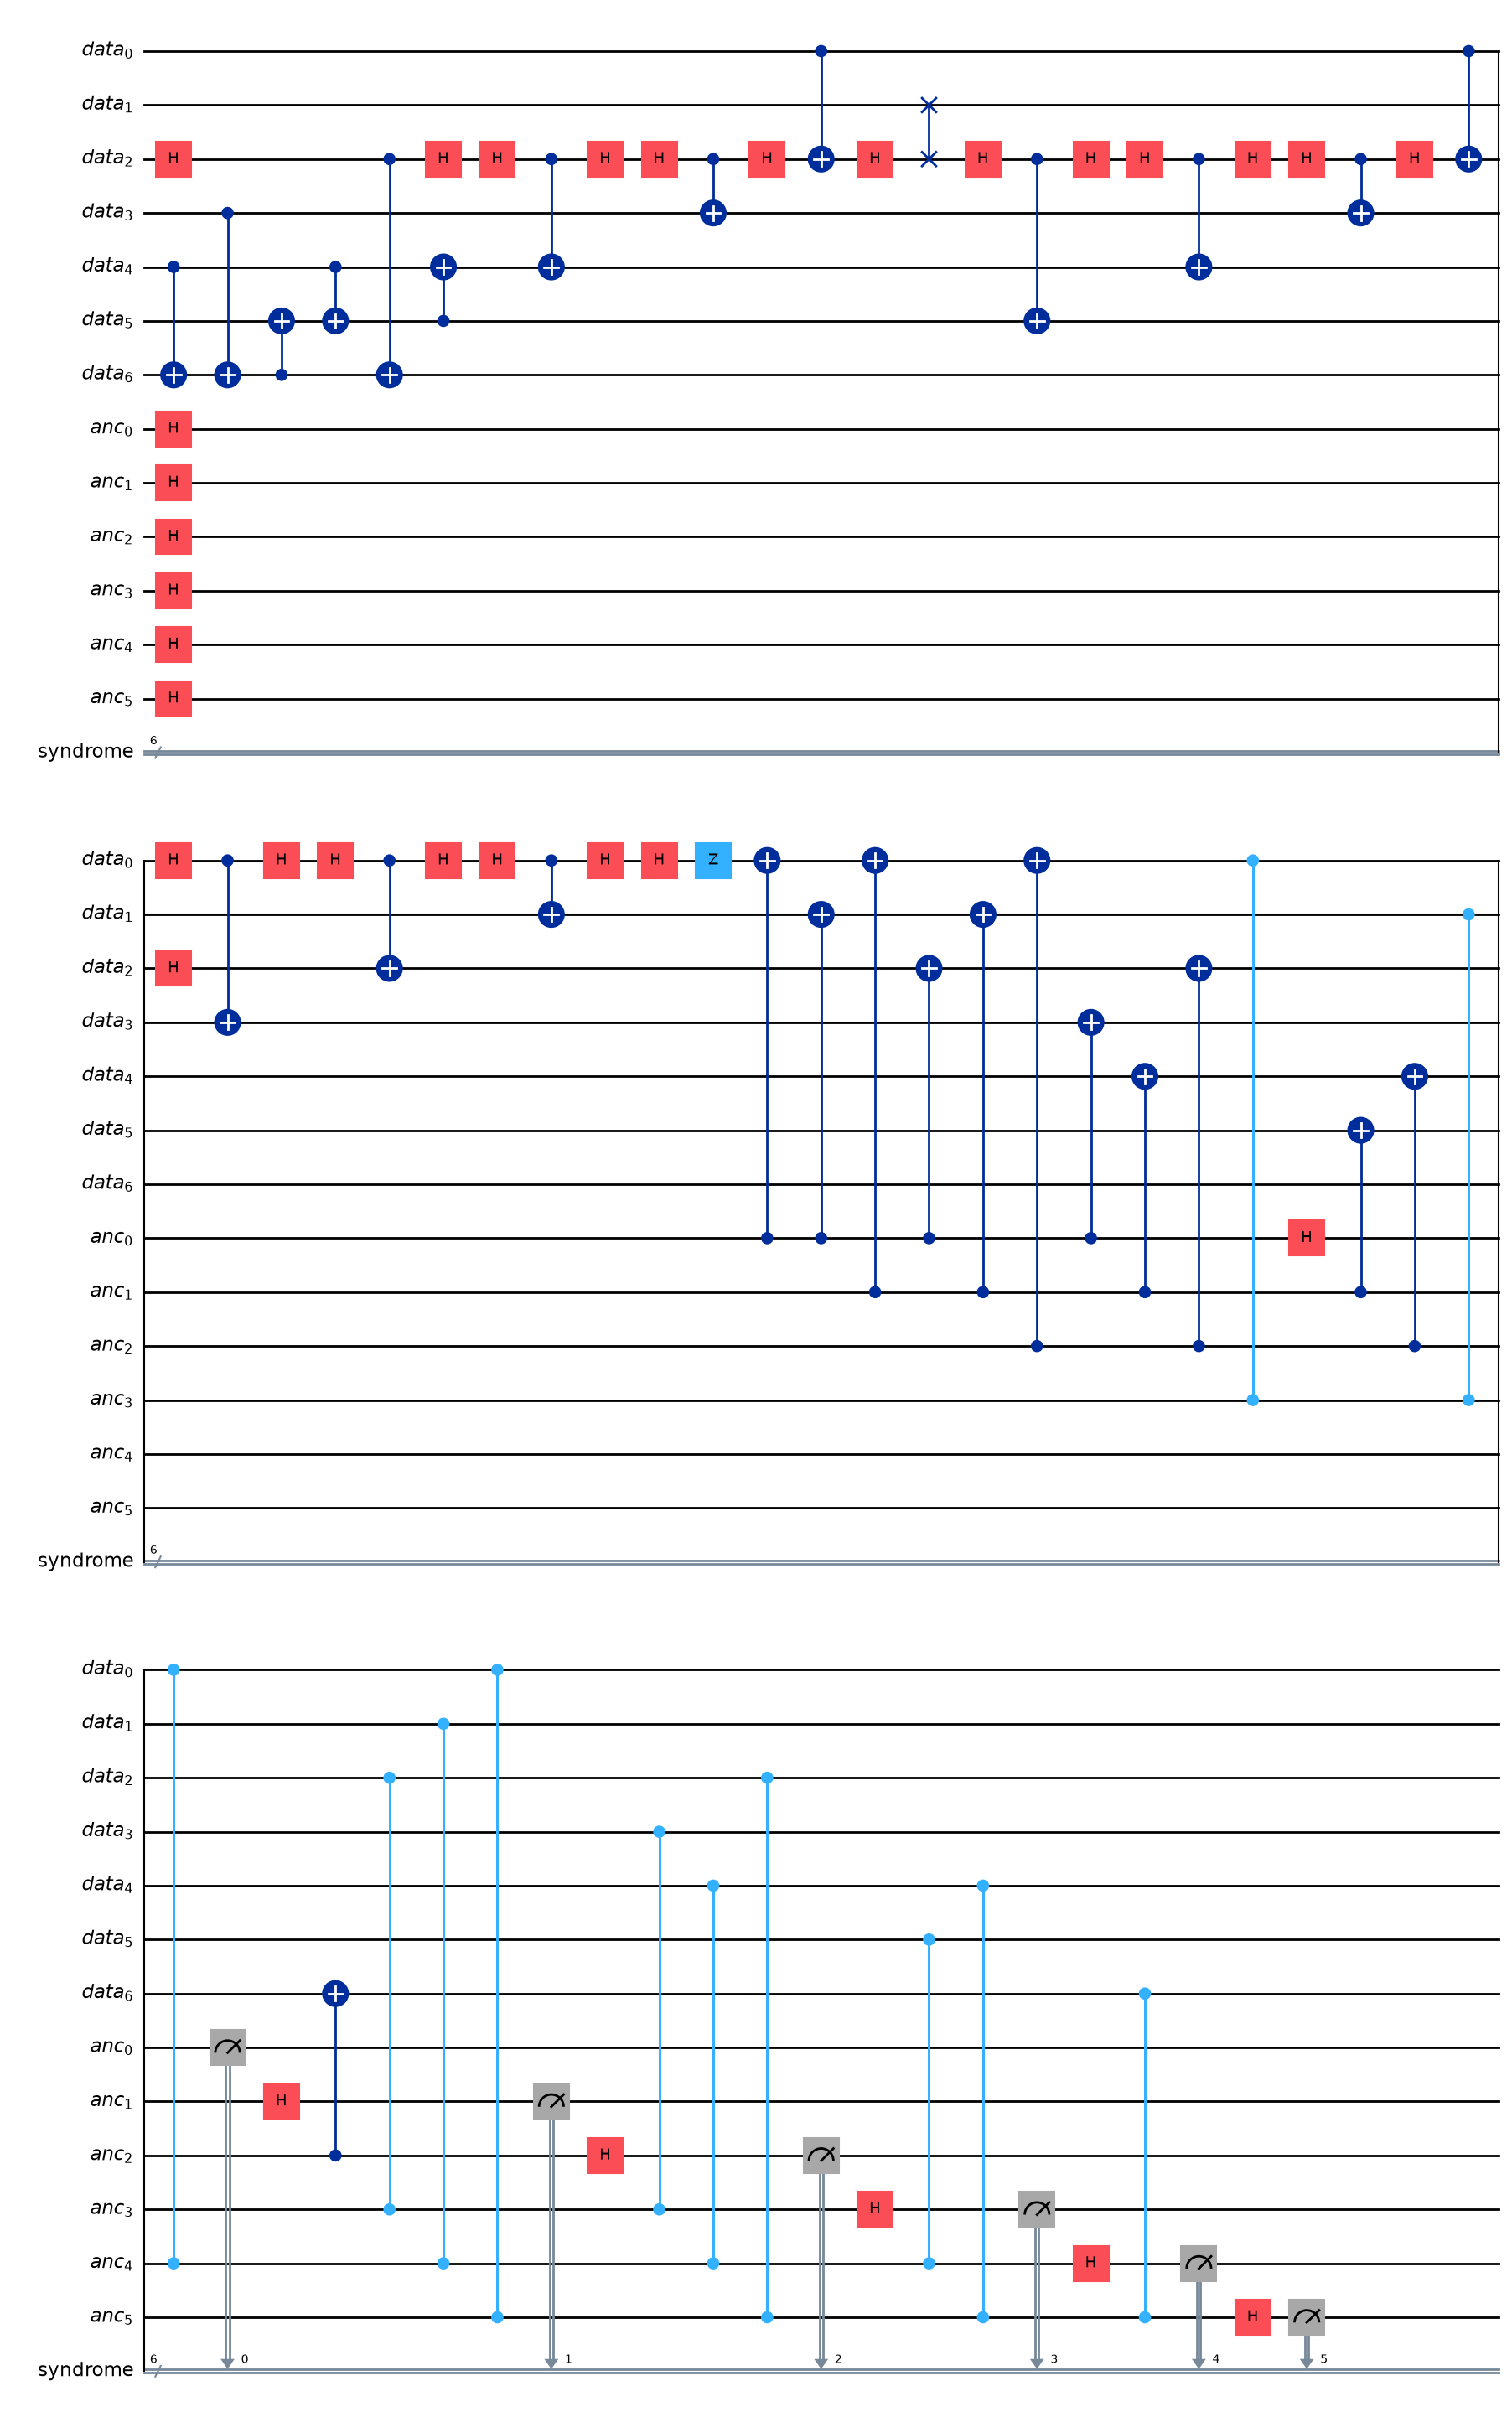

In [20]:
data = QuantumRegister(7, "data")
ancilla = AncillaRegister(6, "anc")
syndrome_bits = ClassicalRegister(6, "syndrome")

qc = QuantumCircuit(data, ancilla, syndrome_bits)

# prepare the logical computational-basis state |0_L>
qc.compose(logical_zero_circuit, qubits=data, inplace=True)

# apply the Pauli error Z_0
qc.z(data[0])

# append the six stabilizer measurements
append_syndrome_measurement(
    qc,
    data,
    ancilla,
    syndrome_bits,
)

qc.draw(output="mpl")

In [21]:
# simulate the Z_0-error case and verify that we obtain the correct syndrome
simulator = AerSimulator()
result = simulator.run(qc, shots=100).result()
counts = result.get_counts()

# verify that the measurement outcome is deterministic
assert len(counts) == 1

# extract the unique classical measurement bitstring
bitstring = next(iter(counts))

# qiskit displays classical bits in reverse order, so reverse the bitstring
# and convert it into a syndrome tuple
measured_syndrome = tuple(int(bit) for bit in bitstring[::-1])

# compare the measured syndrome with the algebraically computed syndrome
assert measured_syndrome == syndrome(Pauli("IIIIIIZ"))

The $Z_0$ example verifies agreement between the algebraic and circuit-based syndrome calculations for one particular error. 

We now repeat the comparison for all $21$ weight-one Pauli errors

$$
X_j,\qquad Y_j,\qquad Z_j,
\qquad j=0,\ldots,6.
$$

For each error, we prepare $|0_L\rangle$, apply the error to the appropriate data qubit, extract the six-bit syndrome using the ancilla-based circuit, and compare the result with the algebraic syndrome returned by `syndrome`.

In [22]:
simulator = AerSimulator()

for pauli_type in ["X", "Y", "Z"]:
    for qubit_index in range(7):
        data = QuantumRegister(7, "data")
        ancilla = AncillaRegister(6, "anc")
        syndrome_bits = ClassicalRegister(6, "syndrome")

        # build a fresh circuit
        qc = QuantumCircuit(data, ancilla, syndrome_bits)

        # prepare the logical computational-basis state |0_L>
        qc.compose(logical_zero_circuit, qubits=data, inplace=True)

        # apply the chosen Pauli error
        if pauli_type == "X":
            qc.x(data[qubit_index])
        elif pauli_type == "Z":
            qc.z(data[qubit_index])
        elif pauli_type == "Y":
            qc.y(data[qubit_index])

        # append syndrome extraction
        append_syndrome_measurement(qc, data, ancilla, syndrome_bits)

        # simulate and recover measured syndrome
        result = simulator.run(qc, shots=100).result()
        counts = result.get_counts()

        assert len(counts) == 1

        bitstring = next(iter(counts))
        measured_syndrome = tuple(int(bit) for bit in bitstring[::-1])

        # build the matching Pauli object
        pauli_error = Pauli("I" * (6 - qubit_index) + pauli_type + "I" * qubit_index)

        # compare circuit and algebraic syndromes
        assert measured_syndrome == syndrome(pauli_error)

The calculation above verifies that the ancilla-based syndrome-extraction circuit agrees with the algebraic syndrome calculation for all $21$ weight-one Pauli errors. For each error $E$, the six measured stabilizer eigenvalues reproduce the syndrome

$$
s(E)\in\mathbb{F}_2^6
$$

computed directly from the commutation relations between $E$ and the stabilizer generators.

Thus, the algebraic and circuit-based descriptions of syndrome extraction agree for every single-qubit Pauli error correctable by the Steane $[[7,1,3]]$ code.

### Simulation Settings and Circuit Resources

All circuit experiments in this notebook use Qiskit's ideal `AerSimulator`
with 100 shots per circuit. No noise model, hardware connectivity constraint,
or hardware-specific transpilation is applied. The circuit diagrams therefore
show the logical gates as constructed rather than a decomposition into a
particular hardware gate basis.

The full Steane syndrome-extraction circuit uses 7 data qubits, 6 ancilla
qubits, and 6 classical syndrome bits. For the chosen weight-four stabilizer
generators, the syndrome-extraction portion of the circuit contains 12
Hadamard gates on the ancillas, 12 controlled-$X$ gates, 12 controlled-$Z$
gates, and 6 ancilla measurements.

The simulated stabilizer measurements considered here are deterministic, so
no numerical tolerance or random seed is required for the syndrome checks.
Classical simulator runtime is not treated as a circuit resource and is not
benchmarked in this stage of the project.

## Summary

In this notebook, we introduced the stabilizer formalism for an $[[n,k,d]]$ stabilizer code, beginning with the $n$-qubit Pauli group, the associated stabilizer group, and the code space as the simultaneous $+1$ eigenspace of the stabilizer generators. We then specialized to the Steane $[[7,1,3]]$ code and fixed a standard CSS generating set.

We defined the syndrome of a Pauli error in terms of its commutation relations with the chosen stabilizer generators and examined several structural properties of the syndrome map. We also interpreted syndromes geometrically through the orthogonal decomposition of the physical Hilbert space into simultaneous stabilizer eigenspaces, showing that a Pauli error maps the code space into the syndrome subspace determined by its syndrome.

For the Steane code, we verified algebraically that the $21$ weight-one Pauli errors have distinct, nonzero syndromes. We then implemented ancilla-based stabilizer measurements and combined the six individual measurements into a complete syndrome-extraction circuit.

To prepare the logical state $|0_L\rangle$, we used Qiskit's stabilizer-synthesis routine with the seven commuting operators

$$
S_1,\ldots,S_6,Z_L.
$$

The first six operators constrain the state to lie in the Steane code space, while the additional $+1$ eigenvalue condition for $Z_L$ selects the logical computational-basis state $|0_L\rangle$. We then verified that the prepared state produces the zero syndrome in the absence of an error and that, after introducing each of the $21$ weight-one Pauli errors, the circuit reproduces the corresponding algebraic syndrome.

The stabilizer-measurement circuit developed here will provide the starting point for the next stage of the project, where we interpret stabilizer measurement in terms of one-bit quantum phase estimation.

## References

1. D. Gottesman, *Stabilizer Codes and Quantum Error Correction*, Ph.D. thesis, California Institute of Technology, 1997. arXiv:quant-ph/9705052.

2. IBM Quantum Learning, “CSS Codes,” *Foundations of Quantum Error Correction*, Quantum Code Constructions.

3. J. K. Iverson and J. Preskill, “Coherence in Logical Quantum Channels,” *New Journal of Physics* **22**, 073066 (2020).

4. IBM Quantum, *Qiskit Documentation: Stabilizer Circuit Synthesis*, documentation for `qiskit.synthesis.synth_circuit_from_stabilizers`.